In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
import matplotlib.pyplot as plt
import copy
from random import shuffle

In [2]:
# The number of qubits used in the quantum circuit
N_WIRES = 2
# The number of clients in our federated learning setup
N_CLIENTS = 3
# The number of training rounds for federated learning
N_ROUNDS = 70
# Number of local training steps on each client per round
LOCAL_EPOCHS = 20
# Batch size for local training
BATCH_SIZE = 5

# Set a random seed for reproducibility
np.random.seed(42)

In [3]:
# --- Functions provided by the user ---

def get_angles(x):
    """Calculates angles for state preparation from an input vector x."""
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))
    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

def state_preparation(a):
    """Encodes classical data into a quantum state."""
    qml.RY(a[0], wires=0)

    qml.CNOT(wires=[0, 1])
    qml.RY(a[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[2], wires=1)

    qml.PauliX(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[3], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[4], wires=1)
    qml.PauliX(wires=0)

def square_loss(labels, predictions):
    """Calculates the mean squared error loss."""
    return np.mean((labels - qml.math.stack(predictions)) ** 2)

def layer(layer_weights):
    """A single variational layer of the quantum circuit."""
    for wire in range(N_WIRES):
        qml.Rot(*layer_weights[wire], wires=wire)
    qml.CNOT(wires=[0, 1])

def cost(weights, bias, X, Y):
    """The cost function to be minimized during training."""
    # Transpose the batch of input data in order to make the indexing
    # in state_preparation work
    predictions = variational_classifier(weights, bias, X.T)
    return square_loss(Y, predictions)

# The quantum device for the circuit simulation
dev = qml.device("default.qubit", wires=N_WIRES)

@qml.qnode(dev)
def circuit(weights, x):
    """The full quantum circuit, combining state preparation and layers."""
    state_preparation(x)
    for layer_weights in weights:
        layer(layer_weights)
    return qml.expval(qml.PauliZ(0))

def variational_classifier(weights, bias, x):
    """The variational quantum classifier."""
    return circuit(weights, x) + bias

def accuracy(labels, predictions):
    """Calculates the accuracy of the predictions."""
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

# --- Federated Learning Logic ---

def prepare_and_split_data():
    """Loads, preprocesses, and splits the Iris dataset into train/validation sets."""
    # Note: For a runnable simulation without external files, we create mock data.
    # In a real scenario, you would uncomment the line below and provide the file.
    data = np.loadtxt("variational_classifier/data/iris_classes1and2_scaled.txt")
    num_samples = 150
    #data = np.random.uniform(-1, 1, (num_samples, 3))
    data[:, 2] = np.sign(data[:, 0] + data[:, 1])

    X = data[:, 0:2]
    Y = data[:, -1]
    
    # Pad the vectors to size 2^2=4 with constant values
    padding = np.ones((len(X), 2)) * 0.1
    X_pad = np.c_[X, padding]

    # Normalize each input
    normalization = np.sqrt(np.sum(X_pad**2, -1))
    X_norm = (X_pad.T / normalization).T

    # The angles for state preparation are the features
    features = np.array([get_angles(x) for x in X_norm], requires_grad=False)
    
    # Split data into training and validation sets
    np.random.seed(0)
    num_data = len(Y)
    num_train = int(0.75 * num_data)
    index = np.random.permutation(range(num_data))
    
    feats_train = features[index[:num_train]]
    Y_train = Y[index[:num_train]]
    feats_val = features[index[num_train:]]
    Y_val = Y[index[num_train:]]

    # We need these later for plotting
    X_train = X[index[:num_train]]
    X_val = X[index[num_train:]]
    
    return feats_train, Y_train, feats_val, Y_val, X_train, X_val

def split_training_data_for_clients(feats_train, Y_train, n_clients):
    """Splits the training dataset into equal parts for each client."""
    indices = list(range(len(feats_train)))
    shuffle(indices)
    split_indices = np.array_split(indices, n_clients)
    client_data = []
    for s_indices in split_indices:
        client_data.append({
            'features': feats_train[s_indices],
            'Y': Y_train[s_indices]
        })
    return client_data

def client_update(local_weights, local_bias, X_local, Y_local):
    """Simulates a client training a local model using mini-batches."""
    print("    - Training client's local model...")
    opt = NesterovMomentumOptimizer(0.01)

    num_local_samples = len(X_local)
    batch_size = BATCH_SIZE

    # Simulate a few local training steps
    for i in range(LOCAL_EPOCHS):
        batch_index = np.random.randint(0, num_local_samples, (batch_size,))
        features_batch = X_local[batch_index]
        Y_batch = Y_local[batch_index]

        # Update weights and bias
        local_weights, local_bias, _, _ = opt.step(cost, local_weights, local_bias, features_batch, Y_batch)
    
    predictions = np.sign([variational_classifier(local_weights, local_bias, x) for x in X_local.T])
    acc = accuracy(Y_local, predictions)
    print(f"    - Client's local accuracy after training: {acc:.4f}")

    return local_weights, local_bias

def server_aggregation(client_weights, client_biases):
    """Aggregates the weights and biases from all clients."""
    print("  - Server is aggregating client models...")
    # Simple averaging of weights and biases
    aggregated_weights = np.mean(np.stack(client_weights), axis=0)
    aggregated_bias = np.mean(np.stack(client_biases), axis=0)
    print("  - Aggregation complete.")
    return aggregated_weights, aggregated_bias



In [4]:
print("Starting federated quantum machine learning simulation...")
# 1. Server initialization
num_layers = 6
num_qubits = 2
weights_shape = (num_layers, num_qubits, 3)
global_weights = 0.01 * np.random.randn(*weights_shape, requires_grad=True)
global_bias = np.array(0.0, requires_grad=True)

Starting federated quantum machine learning simulation...


In [5]:
# 2. Data creation and distribution
feats_train, Y_train, feats_val, Y_val, X_train, X_val = prepare_and_split_data()
client_datasets = split_training_data_for_clients(feats_train, Y_train, N_CLIENTS)
print(f"Loaded dataset and distributed training data to {N_CLIENTS} clients.")

Loaded dataset and distributed training data to 3 clients.


In [6]:
# 3. Federated learning rounds
for round_num in range(N_ROUNDS):
    print(f"\n--- Round {round_num + 1} ---")
    
    # Server broadcasts global model
    client_weights = []
    client_biases = []

    for i, data in enumerate(client_datasets):
        print(f"  - Client {i + 1} receives global model and starts training...")
        
        # Each client gets a copy of the current global model
        local_weights = copy.deepcopy(global_weights)
        local_bias = copy.deepcopy(global_bias)
        
        # Client trains its local model on its private data
        updated_weights, updated_bias = client_update(local_weights, local_bias, data['features'], data['Y'])
        
        # Client sends its updated model back to the server
        client_weights.append(updated_weights)
        client_biases.append(updated_bias)
        
    # Server aggregates models from all clients
    global_weights, global_bias = server_aggregation(client_weights, client_biases)

    # Compute and print global model accuracy on the validation set
    predictions_global = np.sign([variational_classifier(global_weights, global_bias, x) for x in feats_val.T])
    acc_global = accuracy(Y_val, predictions_global)
    print(f"  - Global model accuracy after round {round_num + 1} on validation set: {acc_global:.4f}")

print("\nFederated learning simulation complete.")
print("Final global model weights and bias ready for use.")


--- Round 1 ---
  - Client 1 receives global model and starts training...
    - Training client's local model...
    - Client's local accuracy after training: 0.0800
  - Client 2 receives global model and starts training...
    - Training client's local model...
    - Client's local accuracy after training: 0.0800
  - Client 3 receives global model and starts training...
    - Training client's local model...
    - Client's local accuracy after training: 0.0400
  - Server is aggregating client models...
  - Aggregation complete.
  - Global model accuracy after round 1 on validation set: 0.0800

--- Round 2 ---
  - Client 1 receives global model and starts training...
    - Training client's local model...
    - Client's local accuracy after training: 0.1200
  - Client 2 receives global model and starts training...
    - Training client's local model...
    - Client's local accuracy after training: 0.0400
  - Client 3 receives global model and starts training...
    - Training client's

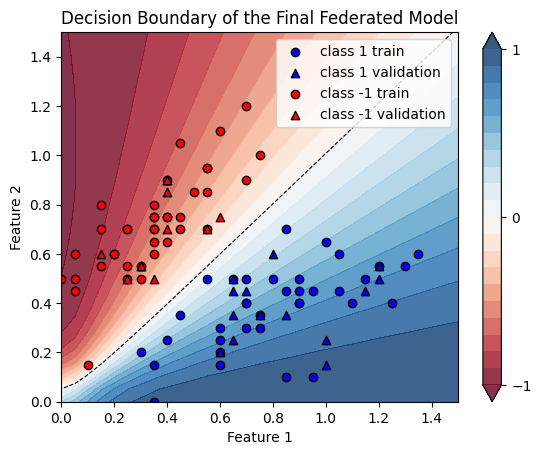

In [7]:
# --- Plotting the decision boundary ---
plt.figure()
cm = plt.cm.RdBu

# Make data for decision regions
xx, yy = np.meshgrid(np.linspace(0.0, 1.5, 30), np.linspace(0.0, 1.5, 30))
X_grid = [np.array([x, y]) for x, y in zip(xx.flatten(), yy.flatten())]

# Preprocess grid points like data inputs above
padding = 0.1 * np.ones((len(X_grid), 2))
X_grid = np.c_[X_grid, padding]  # Pad each input
normalization = np.sqrt(np.sum(X_grid**2, -1))
X_grid = (X_grid.T / normalization).T  # Normalize each input
features_grid = np.array([get_angles(x) for x in X_grid])  # Angles are new features

# Use the final global model to predict on the grid
predictions_grid = variational_classifier(global_weights, global_bias, features_grid.T)
Z = np.reshape(predictions_grid, xx.shape)

# Plot decision regions
levels = np.arange(-1, 1.1, 0.1)
cnt = plt.contourf(xx, yy, Z, levels=levels, cmap=cm, alpha=0.8, extend="both")
plt.contour(xx, yy, Z, levels=[0.0], colors=("black",), linestyles=("--",), linewidths=(0.8,))
plt.colorbar(cnt, ticks=[-1, 0, 1])

# Plot data
for color, label in zip(["b", "r"], [1, -1]):
    plot_x = X_train[:, 0][Y_train == label]
    plot_y = X_train[:, 1][Y_train == label]
    plt.scatter(plot_x, plot_y, c=color, marker="o", ec="k", label=f"class {label} train")
    
    plot_x = (X_val[:, 0][Y_val == label],)
    plot_y = (X_val[:, 1][Y_val == label],)
    plt.scatter(plot_x, plot_y, c=color, marker="^", ec="k", label=f"class {label} validation")

plt.title("Decision Boundary of the Final Federated Model")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()
